# 3D Vector Field Visualization in Porous Media in PyVista

__Author(s):__ Bernard Chang and Masa Prodanovic

__Last Update:__ Jan. 2026

Copyright © 2026 Digital Porous Media Team. All rights reserved.

---

## Objective

Here, we exemplify 3D visualization of a vector field. The example shown in this notebook is an experimentally measured velocity field available on Digital Porous Media Portal. For this purpose a smaller subset has been resized and placed in the data subfolder.

In [ ]:
# Uncomment the following line to install dependencies locally
# %pip install --quiet --upgrade dpm_tools
import dpm_tools as dpm

# Some Utility functions
from pathlib import Path
import sys
sys.path.append("..")
from utils.dataloader import load_sample

# Image processsing
import numpy as np

# Image visualization
import pyvista as pv
import matplotlib.pyplot as plt
pv.set_jupyter_backend('html')
pv.start_xvfb()

download_path = Path("/home/jovyan/work/ls6/dpm_teach_cache")

[16:05:11] ERROR    PARDISO solver not installed, run `pip install pypardiso`. Otherwise,          ]8;id=228406;file://C:\Users\bcc2459\AppData\Roaming\Python\Python312\site-packages\openpnm\utils\_workspace.py\_workspace.py]8;;\:]8;id=257544;file://C:\Users\bcc2459\AppData\Roaming\Python\Python312\site-packages\openpnm\utils\_workspace.py#56\56]8;;\
                    simulations will be slow. Apple M chips not supported.                                         

## Load data and plot a cross section

In the following cell, we load the velocity data and plot a cross section. The velocity data shown here is a $100^3$ subset of an [experimentally measured 3D velocity field in random sphere packing](https://www.doi.org/10.17612/HDP8-0149) that is hosted on the Digital Porous Media Portal.

Loading cached sample 'velocity_x' from dpm_cache\velocity_x.tif
Loading cached sample 'velocity_y' from dpm_cache\velocity_y.tif
Loading cached sample 'velocity_z' from dpm_cache\velocity_z.tif


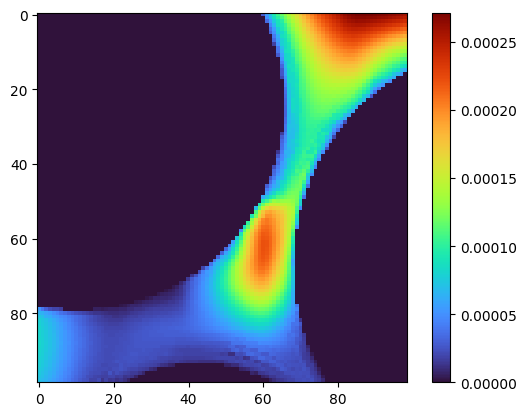

In [ ]:
vx = load_sample("velocity_x", cache_dir=download_path)
vy = load_sample("velocity_y", cache_dir=download_path)
vz = load_sample("velocity_z", cache_dir=download_path)

# compute velocity magnitude
v = np.sqrt(vx**2 + vy**2 + vz**2)

# plot a slice
plot_slice = 20
plt.imshow(v[plot_slice,:,:], cmap='turbo')
plt.colorbar()

## Plot orthogonal cross-sections of velocity magnitude (scalars)

In the following cell, we use PyVista to plot orthogonal cross-sections of the velocity magnitude from the 3D vector field.

In [ ]:
# A function to initialize a PyVista Plotter Object
def initialize_plotter():
    
    # Initialize a PyVista Plotter Object
    plotter_obj = pv.Plotter()
    
    # Set the background color to white
    plotter_obj.set_background(color='w')
    pv.global_theme.font.color = 'black'
    
    return plotter_obj


# A function that plots orthogonal slices through the 3D image
def plot_orthogonal_slices(pv_image_obj, x_slice, y_slice, z_slice):
    ################################################################################ 
    # Input: PyVista image object (wrapped NumPy array), x, y, and z slices to plot
    # Output: PyVista plot of orthogonal slices
    ################################################################################
    
    # Initialize the PyVista plotter object
    p = initialize_plotter()
    
    # Tests to make sure input slices are within image dimensions
    assert x_slice > 0 and x_slice < pv_image_obj.dimensions[0], "X-slice value outside image dimensions"
    assert y_slice > 0 and y_slice < pv_image_obj.dimensions[1], "Y-slice value outside image dimensions"
    assert z_slice > 0 and z_slice < pv_image_obj.dimensions[2], "Z-slice value outside image dimensions"
    
    # Create three orthogonal slices through the dataset at specified X, Y, and Z values
    slices = pv_image_obj.slice_orthogonal(x=x_slice, y=y_slice, z=z_slice)
    
    # Add the slices as meshes to the PyVista plotter object
    p.add_mesh(slices)
    
    # Display the plot
    p.show()

# Wrap 3D NumPy array to PyVista data object
v_img = pv.wrap(v)    

# Get dimensions of the image
x_dim, y_dim, z_dim = v_img.dimensions

# Function call to plot the orthogonal slices.
#plot_orthogonal_slices(v_img, x_dim//2 , y_dim//2, z_dim//2)
plot_orthogonal_slices(v_img, 1 , 1, 1)

Widget(value='<iframe src="http://localhost:64914/index.html?ui=P_0x241bf243fb0_0&reconnect=auto" class="pyvis…

### Using DPM Tools

DPM Tools also provides a wrapper function, ```plot_orthogonal_slices()```, that simplifies working with PyVista by handling the underlying plotting logic.

In [ ]:
velocity_field = dpm.io.Image(scalar=v, vector=[vx, vy, vz])
p = dpm.visualization.orthogonal_slices(velocity_field, show_slices=[1, 1, 1])
p.show()

Widget(value='<iframe src="http://localhost:64914/index.html?ui=P_0x241c82b2e70_1&reconnect=auto" class="pyvis…

## Plot 3D Glyphs Scaled by Velocity Magnitude

In the following cell, we use PyVista to plot 3D glyphs (spheres) scaled by the velocity magnitude. The glyphs are placed on a structured grid, and the size of each glyph is determined by its corresponding velocity magnitude.

In [5]:
# Let's place a sphere of radius that scales as velocity magnitude
n = 100 #linear size of the data above
x = np.linspace(1,n,n)
y = np.linspace(1,n,n)
z = np.linspace(1,n,n)

X, Y, Z = np.meshgrid(x,y,z)
# Get everything spaced right
s = 10      # quiver spacing

Xs = X[::s, ::s, ::s]
Ys = Y[::s, ::s, ::s]
Zs = Z[::s, ::s, ::s]
vs_norm = v[::s, ::s, ::s]/np.max(v)

# Create a structured grid
grid = pv.StructuredGrid(Xs, Ys, Zs)

# Add glyph radii to structured grid data — takes in 1D array
grid["radius"] = vs_norm.ravel()

# Initialize PyVista plotter object
p = initialize_plotter()

# Create a vtk sphere mesh to be plotted
sphere = pv.Sphere(radius=10, phi_resolution=50, theta_resolution=50)

# Use the vtk sphere mesh as glyphs, scaling each sphere by the previously calculated radii
spheres = grid.glyph(scale="radius", geom=sphere)

# Add the glyphs as a mesh to the plotter object
p.add_mesh(spheres, cmap='turbo')

# add grain surface
# Wrap 3D NumPy array to PyVista data object
v_norm = v/np.max(v);
v_norm = np.moveaxis(v_norm, 0, 2)
pv_img = pv.wrap(v_norm)
grain_isosurface = pv_img.contour(isosurfaces=[0.001])

# Add the contoured surface as a mesh to the PyVista plotter object
p.add_mesh(grain_isosurface, color=(153, 255, 255), opacity=0.2)

# Display the plot
p.show()


C:\Users\bcc2459\AppData\Roaming\Python\Python312\site-packages\pyvista\core\filters\data_set.py:1696: UserWarning: No vector-like data to use for orient. orient will be set to False.
  warnings.warn('No vector-like data to use for orient. orient will be set to False.')


Widget(value='<iframe src="http://localhost:64914/index.html?ui=P_0x241b1b83500_2&reconnect=auto" class="pyvis…

## Plot 3D Vector Field as Arrows

In the following cell, we use PyVista to plot 3D vector field as arrows. The arrows are placed on a structured grid, and the length and direction of each arrow are determined by its corresponding velocity vector.

In [6]:
p = initialize_plotter()

# Let's place an arrow in velocity direction at selected points
n = 100 #linear size of the data above
x = np.linspace(1,n,n)
y = np.linspace(1,n,n)
z = np.linspace(1,n,n)

X, Y, Z = np.meshgrid(x,y,z)
# Get everything spaced
s = 10      # glyph spacing

Xs = X[::s, ::s, ::s]
Ys = Y[::s, ::s, ::s]
Zs = Z[::s, ::s, ::s]

# normalize velocity vectors
vx_norm = vx[::s, ::s, ::s]/np.max(v)
vy_norm = vy[::s, ::s, ::s]/np.max(v)
vz_norm = vz[::s, ::s, ::s]/np.max(v)
vs_norm = v[::s, ::s, ::s]/np.max(v)

# Create a structured grid
newgrid = pv.StructuredGrid(Xs, Ys, Zs)
newgrid["vectors"] = np.column_stack((vz_norm.ravel(), vy_norm.ravel(), vx_norm.ravel()))
newgrid["scalars"] = vs_norm.ravel()

# Make a geometric object to use as the glyph
arrow = pv.Arrow(scale=20)
arrows = newgrid.glyph(geom=arrow,orient="vectors",scale="scalars")

p.add_mesh(arrows, cmap='turbo')

# add grain surface
# Wrap 3D NumPy array to PyVista data object
v_norm = v/np.max(v);
v_norm = np.moveaxis(v_norm, 0, 2)
pv_img = pv.wrap(v_norm)
grain_isosurface = pv_img.contour(isosurfaces=[0.001])

# Add the contoured surface as a mesh to the PyVista plotter object
p.add_mesh(grain_isosurface, color=(153, 255, 255), opacity=0.2)

# Display the plot
p.show()



Widget(value='<iframe src="http://localhost:64914/index.html?ui=P_0x241c83477d0_3&reconnect=auto" class="pyvis…

### Using DPM Tools

We can create a similar plot using the DPM Tools wrapper, ```dpm_tools.visualization.plot_glyph()```.

In [ ]:
# Update the scalar field with the binarized image for surface plotting
# velocity_field.scalar = (velocity_field.vector[0] != 0).astype(np.uint8)

# Plot the velocity field using glyphs
p = dpm.visualization.plot_glyph(velocity_field)

# We can add additional meshes to the same plotter object!
dpm.visualization.plot_isosurface(velocity_field, show_isosurface=[1e-6], mesh_kwargs={"color":(153, 255, 255), "opacity":0.2}, fig=p)

p.show()

C:\Users\bcc2459\AppData\Roaming\Python\Python312\site-packages\pyvista\core\utilities\points.py:77: UserWarning: Points is not a float type. This can cause issues when transforming or applying filters. Casting to ``np.float32``. Disable this by passing ``force_float=False``.
  warnings.warn(


Widget(value='<iframe src="http://localhost:64914/index.html?ui=P_0x241bfe1ffb0_5&reconnect=auto" class="pyvis…

## Plot Streamlines

In the following cell, we use PyVista to plot streamlines from the velocity field. Note that this visualization requires a lot of manual adjustments to the plot settings to achieve the desired visualization.



In [ ]:
# Create a uniform 3D grid
mesh = pv.ImageData(
    dimensions=(n, n, n),
    origin=(0, 0, 0),
    spacing=(1, 1, 1)
)

# vectors
vectors = np.column_stack((
    vx.flatten(order="F"),
    vy.flatten(order="F"),
    vz.flatten(order="F")
))
mesh["vectors"] = vectors
# Explicitly tell PyVista which array to use for streamlines
mesh.set_active_vectors("vectors")

# scalar field
v_norm = v / np.max(v)
mesh["v_norm"] = v_norm.flatten(order="F")
# Convert cell-centered scalars to point-centered scalars
mesh = mesh.cell_data_to_point_data()

# generate streamlines
stream, src = mesh.streamlines(
    "vectors",
    return_source=True,
    n_points=200,
    source_radius=50,
    terminal_speed=0.0,
    initial_step_length=2.0
)

# extract an isosurface
grain_isosurface = mesh.contour(
    isosurfaces=[1e-6],
    scalars="v_norm"
)

p.add_mesh(stream.tube(radius=0.34))
p.add_mesh(grain_isosurface, color=(153, 255, 255), opacity=0.2)
p.show()


Widget(value='<iframe src="http://localhost:64914/index.html?ui=P_0x241d9c29c10_6&reconnect=auto" class="pyvis…

### Using DPM Tools

Again, DPM Tools offers a wrapper, ```dpm_tools.visualization.plot_streamlines()```, that can be used to create streamlines from the velocity field. The wrapper attempts to automatically adjust the plot settings to achieve a visually appealing visualization.

In [ ]:
## Plotting the streamlines with a bounding box
fig_streamlines = dpm.visualization.plot_streamlines(velocity_field)

## Adding a bounding box to the streamlines
# dpm.visualization.bounding_box(bentheimer_ss_data, fig=fig_streamlines)
dpm.visualization.plot_isosurface(velocity_field, show_isosurface=[1e-6], fig=fig_streamlines,
                           mesh_kwargs={'color': (153, 255, 255), 'opacity': 0.15})
fig_streamlines.show()

Widget(value='<iframe src="http://localhost:64914/index.html?ui=P_0x241b1ba1cd0_7&reconnect=auto" class="pyvis…

Check out the grid structures by printing the details.

In [10]:
newgrid

StructuredGrid (0x241c832ef20)
  N Cells:      729
  N Points:     1000
  X Bounds:     1.000e+00, 9.100e+01
  Y Bounds:     1.000e+00, 9.100e+01
  Z Bounds:     1.000e+00, 9.100e+01
  Dimensions:   10, 10, 10
  N Arrays:     2

In [11]:
grid

StructuredGrid (0x241c832f100)
  N Cells:      729
  N Points:     1000
  X Bounds:     1.000e+00, 9.100e+01
  Y Bounds:     1.000e+00, 9.100e+01
  Z Bounds:     1.000e+00, 9.100e+01
  Dimensions:   10, 10, 10
  N Arrays:     1